# R2-Dreamer Habitat Baseline — Evaluation

**Goal:** Visualize evaluation results from the R2-Dreamer no-goal baseline on HM3D ObjectNav.

| Property | Value |
|----------|-------|
| Agent | R2-Dreamer (JAX, no goal conditioning) |
| Environment | HM3D ObjectNav (train split, 64x64 RGB) |
| Input | `output/r2dreamer-habitat-baseline/*/eval_results.json` |

Results are produced by `modules/r2dreamer/scripts/eval_habitat.py`.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

In [2]:
# --- Load evaluation results ---
EVAL_PATH = Path("../../../output/r2dreamer-habitat-baseline/sanity-50k/eval_results.json")
assert EVAL_PATH.exists(), f"Not found: {EVAL_PATH}\nRun: uv run python modules/r2dreamer/scripts/eval_habitat.py --checkpoint <ckpt> --output <path>"

with open(EVAL_PATH) as f:
    data = json.load(f)

results = data["results"]
print(f"Loaded {len(results)} episodes from {EVAL_PATH}")
print(f"Checkpoint: {data['checkpoint']}")

Loaded 10 episodes from ../../../output/r2dreamer-habitat-baseline/sanity-50k/eval_results.json
Checkpoint: output/r2dreamer-habitat-baseline/sanity-50k/checkpoints/step_000050000.pkl


## Summary Statistics

In [3]:
successes = [r["success"] for r in results]
rewards = [r["reward"] for r in results]
steps = [r["steps"] for r in results]
spls = [r["spl"] for r in results]

print(f"Episodes:     {len(results)}")
print(f"Success rate: {np.mean(successes)*100:.1f}%")
print(f"Mean SPL:     {np.mean(spls):.3f}")
print(f"Mean reward:  {np.mean(rewards):.2f} (std={np.std(rewards):.2f})")
print(f"Mean steps:   {np.mean(steps):.0f} (median={np.median(steps):.0f})")

Episodes:     10
Success rate: 0.0%
Mean SPL:     0.000
Mean reward:  -0.30 (std=0.52)
Mean steps:   500 (median=500)


## Per-Episode Results

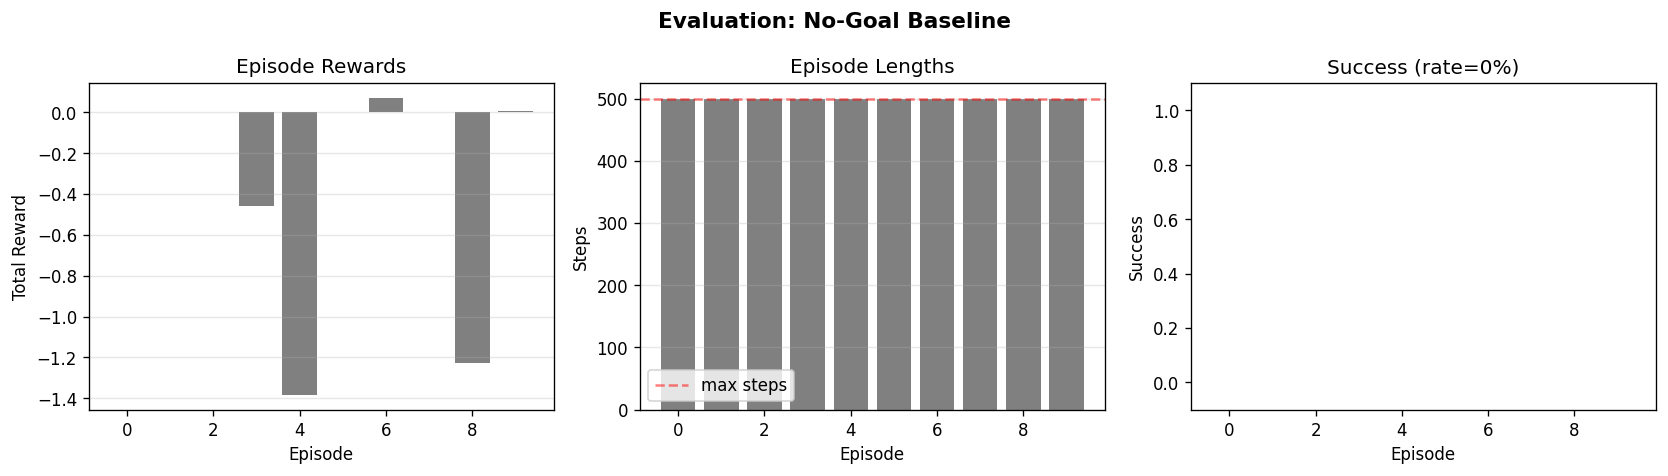

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

eps = range(len(results))

axes[0].bar(eps, rewards, color=["green" if s else "gray" for s in successes])
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].set_title("Episode Rewards")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(eps, steps, color=["green" if s else "gray" for s in successes])
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps")
axes[1].set_title("Episode Lengths")
axes[1].axhline(y=500, color="red", linestyle="--", alpha=0.5, label="max steps")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar(eps, successes)
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Success")
axes[2].set_title(f"Success (rate={np.mean(successes)*100:.0f}%)")
axes[2].set_ylim(-0.1, 1.1)

fig.suptitle("Evaluation: No-Goal Baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Action Distribution

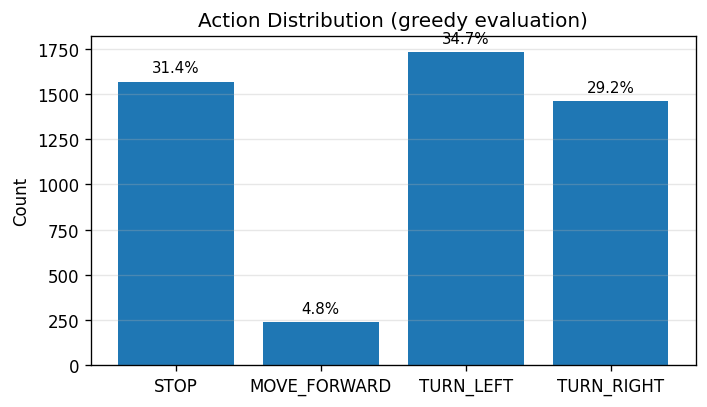

In [5]:
ACTIONS = {"STOP": 0, "MOVE_FORWARD": 1, "TURN_LEFT": 2, "TURN_RIGHT": 3}

# Aggregate action counts across all episodes
total_counts = {name: 0 for name in ACTIONS}
for r in results:
    for name, count in r["action_counts"].items():
        total_counts[name] += count

total = sum(total_counts.values())

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(total_counts.keys(), total_counts.values())

for bar, count in zip(bars, total_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
            f"{count/total*100:.1f}%", ha="center", fontsize=9)

ax.set_ylabel("Count")
ax.set_title("Action Distribution (greedy evaluation)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Reward Distribution

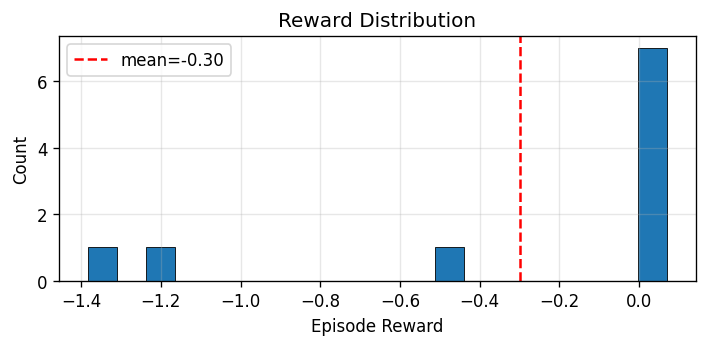

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(rewards, bins=20, edgecolor="black", linewidth=0.5)
ax.axvline(x=np.mean(rewards), color="red", linestyle="--",
           label=f"mean={np.mean(rewards):.2f}")
ax.set_xlabel("Episode Reward")
ax.set_ylabel("Count")
ax.set_title("Reward Distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()